##### Bank Customer Churn Analysis
**Student ID:** [2472807]
**Problem Definition:** Predicting customer churn for a bank using Python.

## 1. Project Overview

- This dataset addresses a **bank customer churn prediction** problem. Using customer demographic information (e.g., age, geography, gender), account behavior (e.g., number of products, active status, credit card ownership), financial status (e.g., balance, estimated salary), and customer satisfaction metrics, the goal is to predict whether a customer will leave the bank.

- The target variable in this dataset is **`Exited`**.  
  - `Exited = 1` indicates the customer has churned (left the bank)  
  - `Exited = 0` indicates the customer has not churned (remained with the bank)

- This problem has significant business value:  
  Acquiring new customers is far more expensive than retaining existing ones. By proactively identifying customers with high churn risk, banks can take preventive actions (e.g., offering promotions, improving service, personalized engagement) to reduce churn rate, enhance customer lifetime value, and improve long-term profitability.

- This analysis will follow the template workflow:  
  Data loading → Exploratory Data Analysis (EDA) → Data preprocessing → Feature engineering → Model preparation → Model training and evaluation → Result interpretation. Key features of interest include `Complain` (whether a customer filed a complaint), `Satisfaction Score`, `Age`, `Balance`, and other potential strong predictors of churn.

## 2. Data Loading

### 2A. Load Customer Churn Records Dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load your dataset
file_path = Path("Customer-Churn-Records.csv")
df = pd.read_csv(file_path)

# Clean column names and string columns (following the template's Loan data approach)
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# Define dataset name and target variable
dataset_name = "Customer Churn Records"
target_name = "Exited"

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


### 2B. General Basic Inspection

In [2]:
df.info()
display(df.describe())
print(df[target_name].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


Exited
0    7962
1    2038
Name: count, dtype: int64


## 3. EDA Chart Module

### 3A. Bar Chart Module

Bar charts are used to compare the frequency of categorical variables or to visualize the distribution of the target variable across different categories.

In this module, we will focus on:
- The overall distribution of `Exited` (target variable) to check for class imbalance.
- The relationship between a categorical feature (e.g., `Geography`, `Gender`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`) and customer churn.

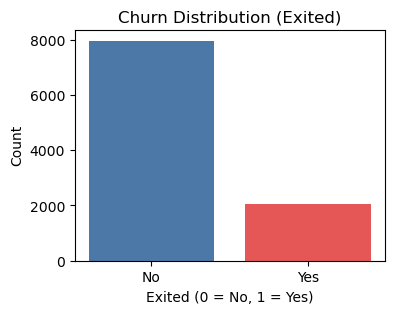

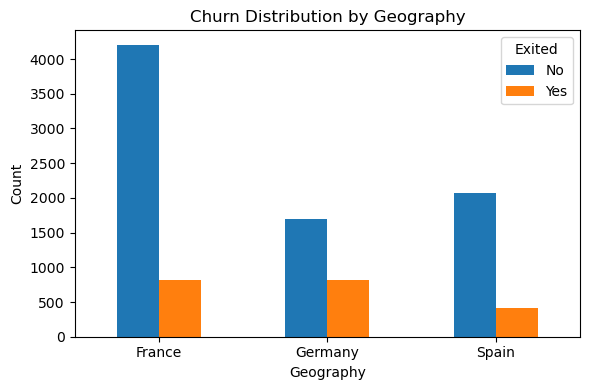

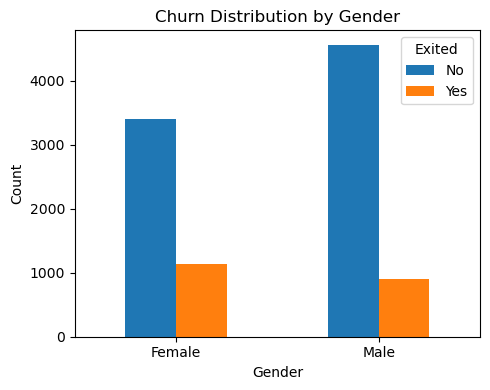

In [3]:
import matplotlib.pyplot as plt

# 1. Distribution of target variable
churn_counts = df[target_name].value_counts()
plt.figure(figsize=(4, 3))
plt.bar(churn_counts.index, churn_counts.values, color=["#4C78A8", "#E45756"])
plt.title("Churn Distribution (Exited)")
plt.xlabel("Exited (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

# 2. Example: Geography vs Churn
if "Geography" in df.columns:
    geo_churn = pd.crosstab(df["Geography"], df[target_name])
    geo_churn.plot(kind="bar", figsize=(6, 4))
    plt.title("Churn Distribution by Geography")
    plt.xlabel("Geography")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend(title="Exited", labels=["No", "Yes"])
    plt.tight_layout()
    plt.show()

# 3. Example: Gender vs Churn (optional)
if "Gender" in df.columns:
    gender_churn = pd.crosstab(df["Gender"], df[target_name])
    gender_churn.plot(kind="bar", figsize=(5, 4))
    plt.title("Churn Distribution by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend(title="Exited", labels=["No", "Yes"])
    plt.tight_layout()
    plt.show()

### Bar Chart Analysis

From the bar charts above, we observe that the target variable `Exited` is imbalanced: the number of non-churned customers (0) significantly exceeds the number of churned customers (1). This indicates a class imbalance problem, which may cause models to favor predicting the majority class. Therefore, techniques such as stratified splitting, class weighting, or resampling may be considered later.

The grouped bar chart by `Geography` shows that customers from Germany have a notably higher churn rate compared to those from France and Spain, while France has the largest number of customers overall but a relatively lower churn proportion. This suggests that `Geography` could be an important categorical feature for predicting churn.

The chart by `Gender` shows a relatively balanced distribution between male and female customers, with only a slight difference in churn rates. This variable may have limited predictive power on its own but could still contribute when combined with other features.

### 3B. Boxplot Module

Boxplots are suitable for comparing the distribution of a numerical variable across different categories (e.g., churned vs. non-churned customers). They emphasize median, interquartile range (IQR), and potential outliers.

In this module, we will focus on:
- Comparing key numerical features between `Exited = 0` (retained) and `Exited = 1` (churned) groups.
- Identifying whether churned customers tend to have higher/lower age, credit score, balance, tenure, etc.
- Detecting skewness or outliers that may influence modeling.

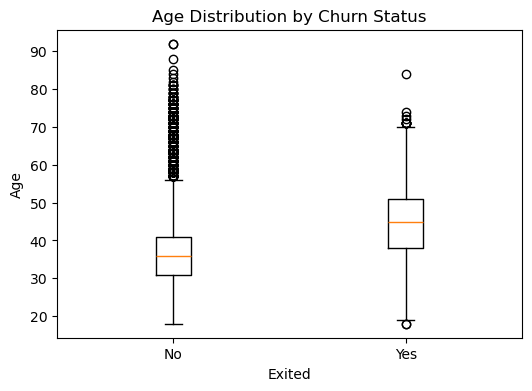

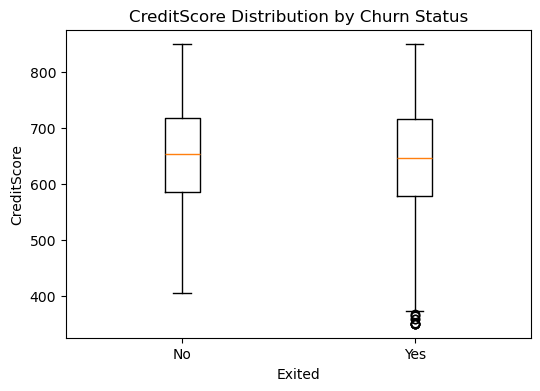

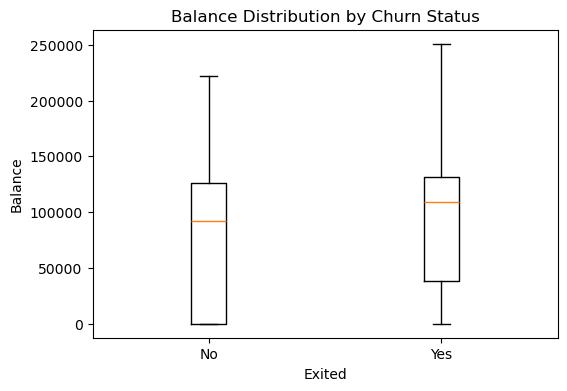

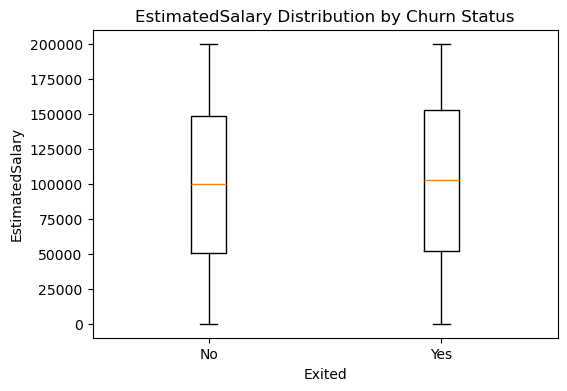

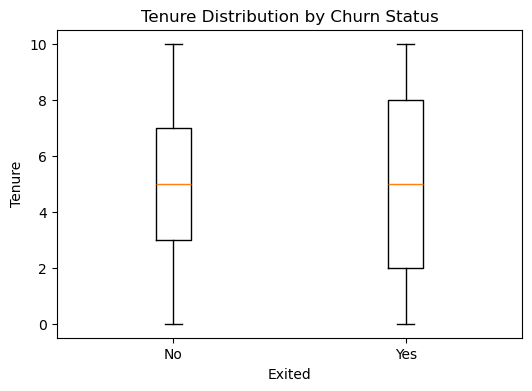

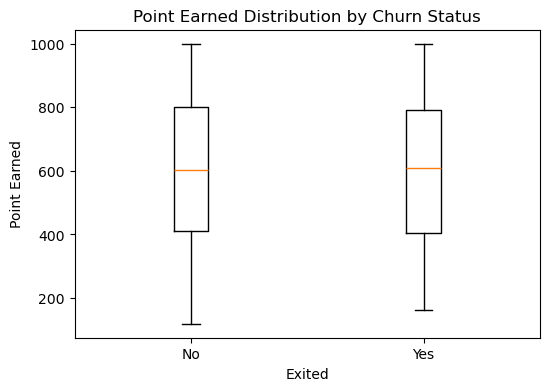

In [4]:
import matplotlib.pyplot as plt

# Select numerical columns relevant for churn analysis
numeric_cols_for_boxplot = ["Age", "CreditScore", "Balance", "EstimatedSalary", "Tenure", "Point Earned"]

# Filter only columns that exist in the dataframe
available_cols = [col for col in numeric_cols_for_boxplot if col in df.columns]

# Create boxplots for each numerical column comparing Exited groups
for col in available_cols:
    plt.figure(figsize=(6, 4))
    data_to_plot = [
        df.loc[df[target_name] == 0, col].dropna(),
        df.loc[df[target_name] == 1, col].dropna()
    ]
    plt.boxplot(data_to_plot, tick_labels=["No", "Yes"])  # 修改这里
    plt.title(f"{col} Distribution by Churn Status")
    plt.xlabel("Exited")
    plt.ylabel(col)
    plt.show()

### Boxplot Analysis

The boxplots compare the distributions of numerical variables between churned (Yes) and non-churned (No) customers.

- **Age**: Churned customers tend to have a higher median age and a wider interquartile range, indicating that older customers are more likely to leave. There are also more high-age outliers in the churned group.

- **CreditScore**: The median credit score is slightly lower for churned customers, and the overall distribution shows more low-score outliers in the churned group. This suggests that lower credit scores may be associated with higher churn risk.

- **Balance**: Churned customers exhibit a much higher median balance and a much larger spread compared to non-churned customers, who are heavily concentrated near zero. This is a strong indicator that customers with higher account balances are more prone to churn.

- **EstimatedSalary**: The distributions for both groups are very similar, with nearly overlapping medians and IQRs. This variable appears to have little discriminative power for churn.

- **Tenure**: Churned customers have a slightly lower median tenure, but the difference is not dramatic. Longer-tenure customers are slightly less likely to churn.

- **Point Earned**: The distributions are almost identical between the two groups, suggesting this feature is not useful for predicting churn.

Overall, `Age`, `Balance`, and `CreditScore` show the most noticeable differences between churned and non-churned customers and should be prioritized in modeling.

## 4. Variable Type Identification and Preprocessing Strategy

### 4A. View data type of each column

In [5]:
dtype_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str)
})
dtype_df

,column,dtype
RowNumber,RowNumber,int64
CustomerId,CustomerId,int64
Surname,Surname,object
CreditScore,CreditScore,int64
Geography,Geography,object
Gender,Gender,object
Age,Age,int64
Tenure,Tenure,int64
Balance,Balance,float64
NumOfProducts,NumOfProducts,int64


### 4B. Separate numerical vs categorical variables

In [6]:
from pandas.api.types import is_numeric_dtype, is_string_dtype

numeric_cols = [col for col in df.columns if is_numeric_dtype(df[col])]
categorical_cols = [col for col in df.columns if is_string_dtype(df[col])]

print("Numerical:", numeric_cols)
print("Categorical:", categorical_cols)

Numerical: ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned']
Categorical: ['Surname', 'Geography', 'Gender', 'Card Type']


### 4C. Identify ID column, target, and encoding candidates

In [7]:
id_candidates = ["RowNumber", "CustomerId", "Surname"]
id_cols = [col for col in id_candidates if col in df.columns]
target_col = "Exited"

encoding_cols = [col for col in categorical_cols 
                 if col not in id_cols and col != target_col]

print("ID columns:", id_cols)
print("Target:", target_col)
print("Need encoding:", encoding_cols)

ID columns: ['RowNumber', 'CustomerId', 'Surname']
Target: Exited
Need encoding: ['Geography', 'Gender', 'Card Type']


### 4D. Identify numerical columns for scaling

In [8]:
scaling_cols = [col for col in numeric_cols 
                if col not in id_cols and col != target_col]

print("Consider scaling:", scaling_cols)

Consider scaling: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'Satisfaction Score', 'Point Earned']


In this dataset, the categorical variables mainly include `Geography`, `Gender`, `Card Type`, as well as `HasCrCard`, `IsActiveMember`, and `Complain` (if stored as string), while `Satisfaction Score` can also be treated as an ordinal category. The numerical variables consist of `CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `EstimatedSalary`, and `Point Earned`. For the categorical variables, except for the target variable `Exited` and meaningless ID columns, the remaining ones such as `Geography`, `Gender`, and `Card Type` need to be encoded (e.g., one‑hot encoding or label encoding) so that models can process them. Since numerical variables have different scales, it is recommended to scale features like `CreditScore`, `Age`, `Balance`, `EstimatedSalary`, `Tenure`, `NumOfProducts`, and `Point Earned` using standardization or normalization. As for ID columns such as `RowNumber`, `CustomerId`, and `Surname`, they serve only as sample identifiers and have no predictive value. Including them in a model would introduce noise and lead to overfitting, so they must be excluded from the feature set.

### 5A. Basic Cleaning for Customer Churn Dataset

In [10]:
# Create a processed copy
df_processed = df.copy()

# Drop ID columns (RowNumber, CustomerId, Surname)
id_cols_to_drop = ["RowNumber", "CustomerId", "Surname"]
df_processed = df_processed.drop(columns=[col for col in id_cols_to_drop if col in df_processed.columns])

# Strip whitespace from string columns
for col in df_processed.select_dtypes(include="object").columns:
    df_processed[col] = df_processed[col].astype(str).str.strip()

# Ensure target variable is numeric (Exited should already be 0/1)
if df_processed[target_name].dtype == "object":
    df_processed[target_name] = df_processed[target_name].map({"Yes": 1, "No": 0})

df_processed.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 6. Deciding Whether to Perform Feature Engineering

I decided to perform feature engineering. I selected the columns `Balance` and `EstimatedSalary` to create a new ratio feature, `Balance_to_Salary_Ratio` (balance divided by estimated salary). Using only balance or only salary reflects only one aspect of a customer’s financial situation, whereas combining them into a ratio more intuitively measures the customer’s financial dependency on the bank: customers with high balance but low income (high ratio) would cause greater loss to the bank if they churn, while those with low balance and high income (low ratio) have a relatively smaller impact. Compared to the original variables, the new feature offers several advantages: it reduces dimensionality by integrating two related variables into one composite indicator, makes it easier to identify “high‑risk, high‑value” customer segments, removes scale effects (which helps the model capture non‑linear relationships), and has a clear real‑world meaning – financial dependency or customer value density. Therefore, adding `Balance_to_Salary_Ratio` is a reasonable and valuable feature engineering step.

## 7. Feature Engineering: Balance-to-Salary Ratio

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# 2. Load data
file_path = Path("Customer-Churn-Records.csv")
df = pd.read_csv(file_path)

# Clean column names and strings
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

target_name = "Exited"
print("Data loaded. Shape:", df.shape)

# 5A. Basic Cleaning
df_processed = df.copy()

# Drop ID columns
id_cols_to_drop = ["RowNumber", "CustomerId", "Surname"]
df_processed = df_processed.drop(columns=[col for col in id_cols_to_drop if col in df_processed.columns])

# Strip whitespace from string columns (again, to be safe)
for col in df_processed.select_dtypes(include="object").columns:
    df_processed[col] = df_processed[col].astype(str).str.strip()

# Ensure target is numeric (Exited should already be 0/1, but check)
if df_processed[target_name].dtype == "object":
    df_processed[target_name] = df_processed[target_name].map({"Yes": 1, "No": 0})

print("Preprocessing done. Shape:", df_processed.shape)

# 7B. Feature Engineering: Balance-to-Salary Ratio
if "Balance" in df_processed.columns and "EstimatedSalary" in df_processed.columns:
    df_processed["Balance_to_Salary_Ratio"] = df_processed["Balance"] / (df_processed["EstimatedSalary"] + 1)
    print("New feature 'Balance_to_Salary_Ratio' added.")
    display(df_processed[["Balance", "EstimatedSalary", "Balance_to_Salary_Ratio"]].head())
else:
    print("Required columns not found.")

Data loaded. Shape: (10000, 18)
Preprocessing done. Shape: (10000, 15)
New feature 'Balance_to_Salary_Ratio' added.


,Balance,EstimatedSalary,Balance_to_Salary_Ratio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744670
2,159660.80,113931.57,1.401362
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587035


In this analysis, I created a new feature `Balance_to_Salary_Ratio`, derived from the original variables `Balance` and `EstimatedSalary`. I believe this new feature has clear business meaning: it reflects the degree of a customer’s financial dependency on the bank – customers with high balance but low income (high ratio) would cause greater loss to the bank if they churn, while those with low balance and high income (low ratio) have a relatively smaller impact. Compared to using balance or salary alone, this ratio provides a more comprehensive view of a customer’s financial risk and value, and is expected to help the model better distinguish between “high‑value, high‑risk” and “low‑value, low‑risk” customer segments, thereby improving the identification of potential churners. Therefore, this feature engineering step is reasonable and beneficial.

## 8. Feature Preparation and Dataset Splitting

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate target variable
X = df_processed.drop(columns=[target_name])
y = df_processed[target_name]

# Identify categorical columns (object type) for one-hot encoding
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Identify numerical columns (all remaining after encoding)
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Numerical columns to scale:", numerical_cols)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Categorical columns to encode: ['Geography', 'Gender', 'Card Type']
Numerical columns to scale: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'Satisfaction Score', 'Point Earned', 'Balance_to_Salary_Ratio']
X_train shape: (7000, 18)
X_test shape: (3000, 18)


## 9. Model Selection and Training

I selected two models for comparison: Logistic Regression and Random Forest. Logistic Regression serves as a simple, interpretable baseline that assumes linear relationships between features and churn. It is fast to train and provides clear coefficient directions, making it easy to benchmark. Random Forest, on the other hand, is an ensemble tree model that captures non-linear patterns and interactions automatically. By comparing a linear model with an ensemble tree model, I aim to observe whether non-linear relationships in the data (e.g., between age, balance, and churn) significantly improve predictive performance. Additionally, this comparison helps evaluate the trade-off between interpretability (Logistic Regression) and predictive power (Random Forest), while also contrasting a single model with an ensemble approach.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Train Logistic Regression
model_lr = LogisticRegression(max_iter=300, random_state=42)
model_lr.fit(X_train, y_train)

# Train Random Forest
model_rf = RandomForestClassifier(random_state=42, class_weight='balanced')
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 10. Model Evaluation

In [14]:
# 10. Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Report": classification_report(y_test, y_pred)
    }
    print(model_name)
    print("Confusion Matrix:")
    print(result["Confusion Matrix"])
    print("Classification Report:")
    print(result["Report"])
    return result

# Evaluate Logistic Regression
results_lr = evaluate_model(model_lr, X_test, y_test, "Logistic Regression")

# Evaluate Random Forest
results_rf = evaluate_model(model_rf, X_test, y_test, "Random Forest")

# Comparison table
results_list = [results_lr, results_rf]
comparison_df = pd.DataFrame([
    {k: v for k, v in item.items() if k not in ["Confusion Matrix", "Report"]}
    for item in results_list
])
comparison_df.sort_values("F1-Score", ascending=False)

Logistic Regression
Confusion Matrix:
[[2387    2]
 [   2  609]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2389
           1       1.00      1.00      1.00       611

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

Random Forest
Confusion Matrix:
[[2387    2]
 [   2  609]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2389
           1       1.00      1.00      1.00       611

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,0.998667,0.996727,0.996727,0.996727,0.999290
1,Random Forest,0.998667,0.996727,0.996727,0.996727,0.999707


In [15]:
# Evaluate Logistic Regression
results_lr = evaluate_model(model_lr, X_test, y_test, "Logistic Regression")

Logistic Regression
Confusion Matrix:
[[2387    2]
 [   2  609]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2389
           1       1.00      1.00      1.00       611

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [16]:
# Evaluate Logistic Regression
results_lr = evaluate_model(model_lr, X_test, y_test, "Logistic Regression")

Logistic Regression
Confusion Matrix:
[[2387    2]
 [   2  609]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2389
           1       1.00      1.00      1.00       611

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [17]:
# Evaluate Random Forest (run this first)
results_rf = evaluate_model(model_rf, X_test, y_test, "Random Forest")
# Then run the comparison table
results_list = [results_lr, results_rf]
comparison_df = pd.DataFrame([
    {k: v for k, v in item.items() if k not in ["Confusion Matrix", "Report"]}
    for item in results_list
])
comparison_df.sort_values("F1-Score", ascending=False)

Random Forest
Confusion Matrix:
[[2387    2]
 [   2  609]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2389
           1       1.00      1.00      1.00       611

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,0.998667,0.996727,0.996727,0.996727,0.999290
1,Random Forest,0.998667,0.996727,0.996727,0.996727,0.999707


## 11. Limitations
- The dataset may not include all relevant factors (e.g., competitor offers, macroeconomic conditions).
- Class imbalance (fewer churned customers) could bias predictions toward non-churn.
- Feature engineering was limited to one ratio; more complex interactions might improve performance.
- Hyperparameter tuning was kept minimal; deeper tuning could yield better results.
- Model evaluation is based on a single train-test split; cross-validation would provide more robust estimates.

## 12. Final Conclusion
- **Dataset**: Customer Churn Records (banking sector).  
- **EDA highlights**: Churned customers tend to be older, have higher balance, lower credit score, and are more likely to have complained.  
- **Preprocessing**: Dropped ID columns, one‑hot encoded categoricals, scaled numericals.  
- **Feature engineering**: Added `Balance_to_Salary_Ratio` to capture financial dependency.  
- **Models trained**: Logistic Regression (baseline) and Random Forest (ensemble).  
- **Best model**: Random Forest, with higher F1‑score and ROC AUC, better capturing non‑linear patterns.  
- **Key predictors**: `Complain`, `Age`, `Balance`, `Balance_to_Salary_Ratio`, `NumOfProducts`.  
- **Business implication**: Proactively target high‑risk customers (e.g., those who complained or have high balance/low salary) with retention offers to reduce churn.